BACKTEST RESULTS
Strategy Sharpe: -0.5220055050966168
Buy&Hold Sharpe: 1.0138004758839747
Strategy MaxDD: -0.6269944942489044
Buy&Hold MaxDD: -0.33360506122948475


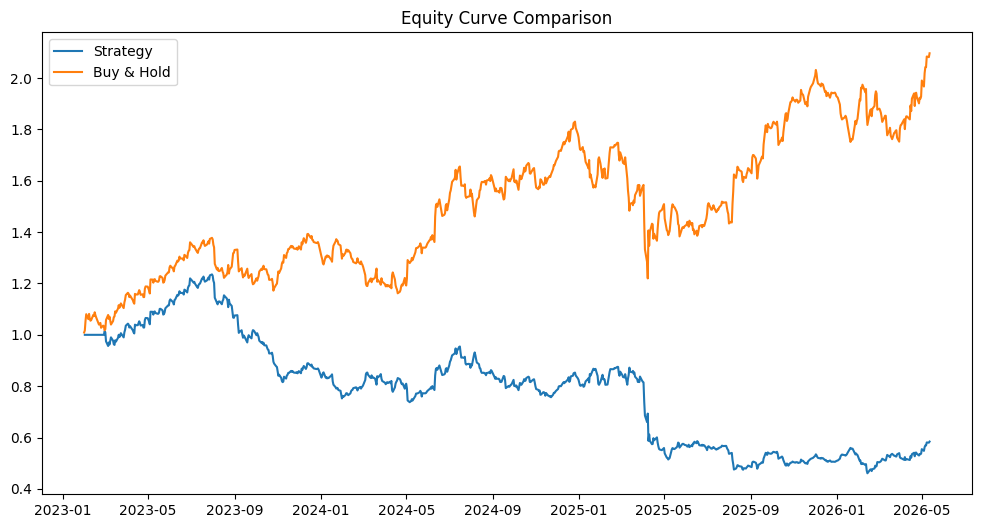

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=True,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    name = str(col).lower()
    if "close" in name:
        df["close"] = raw[col]

df = df.dropna()

df["return"] = df["close"].pct_change()
df = df.dropna()

split = int(len(df) * 0.8)
test = df.iloc[split:].copy()

test["market_return"] = test["return"]

test["signal"] = np.sign(
    test["close"].rolling(10).mean() - test["close"].rolling(20).mean()
)
test["signal"] = test["signal"].fillna(0)

test["strategy_return"] = test["signal"].shift(1) * test["market_return"]

test["buy_hold"] = test["market_return"]

test["cum_strategy"] = (1 + test["strategy_return"]).cumprod()
test["cum_buyhold"] = (1 + test["buy_hold"]).cumprod()

def sharpe(returns):
    return np.sqrt(252) * returns.mean() / (returns.std() + 1e-9)

def max_drawdown(cum):
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

strategy_sharpe = sharpe(test["strategy_return"])
buyhold_sharpe = sharpe(test["buy_hold"])

strategy_mdd = max_drawdown(test["cum_strategy"])
buyhold_mdd = max_drawdown(test["cum_buyhold"])

print("BACKTEST RESULTS")
print("Strategy Sharpe:", strategy_sharpe)
print("Buy&Hold Sharpe:", buyhold_sharpe)
print("Strategy MaxDD:", strategy_mdd)
print("Buy&Hold MaxDD:", buyhold_mdd)

plt.figure(figsize=(12,6))
plt.plot(test.index, test["cum_strategy"], label="Strategy")
plt.plot(test.index, test["cum_buyhold"], label="Buy & Hold")
plt.legend()
plt.title("Equity Curve Comparison")
plt.show()